# Using a pretrained model: ResNet18

ResNet18 is trained on ImageNet on pictures of dogs and cars ect. So it has learned to detect general patterns on a picture. I use this as a starting point for now teaching it to recognise different spectogram-pictures. 18 means it has 18 layers with learnable weights.

People often use pretrained models for cases where you have little training data (not a problem for us), for fine grained problems (then it would mabey be more usefull for the multi-label problem) or starting with a stong baseline for the architechture (my biggest benefit). I am experimenting with seeing if pretrained weights outperforms my homebuilt CNN. If the difference is small, it might be because of the domaine difference of a picture of a dog vs a picture of a spectogram (of a dog barking for example.)

Se notes on what the AudioResNet function is defined as in the doc-string, and what the training loop does in the comment at the trainning loop. Every epoch takes longer time to run, as ResNet has 11M pretrained weights that are being updated.

After successfully running one epoch of this model, I can conclude that it has a stronger start with a better mAP for the first epoch, but it takes 30 minutes pr epoch (15 times longer than my CNN). I can run it for 15 hours over the night to see the result.

It is also possible to choose another pretrained model with more domaine specific training, I can either try that now if I have time, or we can mention is as a natural next step for what we would have done if we had more time or were to continue working on this. To options is VGGish and PANNs which both have trained on AudioSet (which is where FSD50K has ontology from, but not where the actual audio files are from, so my evaluation data is safe. These models have trained on youtube audio files). VGGish (is a feature extractor from google, not a classifier) and PANNs has the same labels as me already. PANNs would be the better choice as it newer, is more flexible on input format and outperforms VGGish. 

In [1]:
from __future__ import print_function, division                     # Ensures Python3 printing & division standard
import IPython.display as ipd                                       #For displaying audio in Jupyter notebooks
import json
import librosa                                                      #For audio processing                    
import matplotlib.pyplot as plt                                     #For creating plots 
import numpy as np                                                  #For numerical operations
import optuna                                                       #For hyperparameter optimization
from optuna.pruners import MedianPruner
import os                                                           #For interacting with the operating system
import pandas as pd                                                 #For data manipulation and analysis 
import random
import seaborn as sns                                               #For statistical data visualization
from sklearn.metrics import roc_curve, auc, average_precision_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, label_binarize
import time
import torch
from torch import nn
import torchaudio.transforms as T
import torch.nn.functional as F                                       #For focal loss               
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import torchvision.models as models
from tqdm import tqdm
import urllib.request

np.random.seed(42)
random.seed(42)

In [2]:
# Set the path to data
DATA_PATH = "/Users/livajuliesmidt/Desktop/ML/AppliedML2026/FinalProject_Liva/FP_data"

dev_labels = pd.read_csv(f"{DATA_PATH}/FSD50K.ground_truth/dev.csv")
train_labels = dev_labels[dev_labels["split"] == "train"]
val_labels = dev_labels[dev_labels["split"] == "val"]
eval_labels = pd.read_csv(f"{DATA_PATH}/FSD50K.ground_truth/eval.csv")

subset_percentage = 100
print(f"Using {subset_percentage}% of the training data equaling {int(len(train_labels) * subset_percentage / 100)} samples")
train_subset = train_labels.sample(n=int(len(train_labels) * subset_percentage / 100), random_state=42)

Using 100% of the training data equaling 36796 samples


In [3]:
#Function for extracting the spectrogram from an audio file, ensuring a fixed shape of (64, 216)
TARGET_SR = 22050                                       #Sample rate
DURATION = 5.0                                          #Seconds to keep (clip/pad to this length)
N_MELS = 64                                             #Number of mel bands to generate (bins in the spectrogram)
HOP_LENGTH = 512                                        #Number of samples between successive frames in the spectrogram
N_FRAMES = int(TARGET_SR * DURATION / HOP_LENGTH) + 1   #Number of frames in the spectrogram (~216 frames)

    
def extract_spectrogram(filepath):
    try:
        audio, sr = librosa.load(filepath, sr=TARGET_SR, duration=DURATION, mono=True)
        
        # Tile (repeat) if shorter than 5 seconds
        expected_samples = int(TARGET_SR * DURATION)
        if len(audio) < expected_samples:
            repeats = -(-expected_samples // len(audio))
            audio = np.tile(audio, repeats)[:expected_samples]
        
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = mel_db[:, :N_FRAMES]  # Trim only — padding is already handled above
        
        return mel_db  # Shape: (64, 216)
    except:
        return None

In [4]:
print("Extracting 2D spectrograms from train split...")
spectrograms = []
valid_idx = []  

for i, row in tqdm(train_subset.iterrows(), total=len(train_subset)):
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_train = np.array(spectrograms)              # (n_clips, 64, 216)
X_train = X_train[:, np.newaxis, :, :]        # (n_clips, 1, 64, 216) — channel dim for CNN
train_true = train_subset.loc[valid_idx].reset_index(drop=True) # Keep only successfully processed samples

print(f"X_train shape: {X_train.shape}")

print(f"Number of successfully processed samples: {len(train_true)}")
print(f"Number of unsuccessful samples: {len(train_subset) - len(train_true)}")

Extracting 2D spectrograms from train split...


  0%|          | 0/36796 [00:00<?, ?it/s]

100%|██████████| 36796/36796 [03:48<00:00, 160.72it/s]


X_train shape: (36796, 1, 64, 216)
Number of successfully processed samples: 36796
Number of unsuccessful samples: 0


In [ ]:
print("Extracting 2D spectrograms from validation split...")
spectrograms = []
valid_idx = []

for i, row in tqdm(val_labels.iterrows(), total=len(val_labels)):
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_val = np.array(spectrograms)              # (n_clips, 64, 216)
X_val = X_val[:, np.newaxis, :, :]        # (n_clips, 1, 64, 216) — channel dim for CNN
val_true = val_labels.loc[valid_idx].reset_index(drop=True) # Keep only successfully processed samples

print(f"X_val shape: {X_val.shape}")

print(f"Number of successfully processed samples: {len(val_true)}")
print(f"Number of unsuccessful samples: {len(val_labels) - len(val_true)}")


Extracting 2D spectrograms from validation split...


100%|██████████| 4170/4170 [00:28<00:00, 146.59it/s]


X_val shape: (4170, 1, 64, 216)
Number of successfully processed samples: 4170
Number of unsuccessful samples: 0


: 

In [ ]:
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std  # use train stats, not val stats!

: 

In [ ]:
url = "https://raw.githubusercontent.com/audioset/ontology/master/ontology.json"
urllib.request.urlretrieve(url, "ontology.json")

with open("ontology.json") as f:
    ontology = json.load(f)

ontology_by_id = {entry["id"]: entry for entry in ontology}     # Build a lookup: mid → full entry

child_to_parent = {}                                            # Build a reverse lookup: child_mid → parent_mid
for entry in ontology:
    for child_id in entry["child_ids"]:
        child_to_parent[child_id] = entry["id"]


top_level = {                                                   # The 6 top-level family MIDs (updated to match the discovered ontology structure)
    "/m/0dgw9r": "Human sounds",
    "/m/0jbk":   "Animal",
    "/m/04rlf":  "Music",
    "/m/059j3w": "Natural sounds",
    "/t/dd00041": "Sounds of things",
    "/t/dd00098": "Source-ambiguous sounds",
}

def get_top_level_family(mid):
    current = mid
    while current not in top_level:
        parent = child_to_parent.get(current)
        if parent is None:
            return "Unknown"                                    # shouldn't happen for FSD50K classes
        current = parent
    return top_level[current]

train_true["family"] = train_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))
val_true["family"] = val_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))


: 

In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(train_true["family"])

print(train_true["family"].value_counts())
print(f"Classes: {len(le.classes_)}, y_train shape: {y_train.shape}")


family
Sounds of things           11669
Music                      11476
Human sounds                6540
Animal                      2684
Source-ambiguous sounds     2567
Natural sounds              1860
Name: count, dtype: int64
Classes: 6, y_train shape: (36796,)


: 

In [ ]:
# --- Create these ONCE, before the objective function ---
X_train_t = torch.tensor(X_train, dtype=torch.float32)                                                          #Convert training data to PyTorch tensor of type float32
y_train_t = torch.tensor(y_train, dtype=torch.long)                                                             #Convert training labels to PyTorch tensor of type long (integer class indices) 
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t  = torch.tensor(le.transform(val_true["family"]), dtype=torch.long)

n_classes = len(le.classes_)                                                                                    #Number of unique classes in the dataset
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")                                    #Use Apple Silicon GPU if available, otherwise CPU
X_val_t_device = X_val_t.to(device)

class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[label] for label in y_train], dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

: 

In [ ]:
from datetime import datetime

number_of_epochs = 16

# --- Hyperparameters ---
lr           = 5.794088198249058e-05
dropout      = 0.20101305365481736
batch_size   = 64 #32
weight_decay = 0.0008002473325738101

# --- ResNet18 adapted for single-channel spectrograms ---
class AudioResNet18(nn.Module):
    def __init__(self, n_classes, dropout):
        """I have made to adaptions to the original ResNet18 architecture:
        1) The first convolutional layer is modified to accept 1-channel input instead of 3-channel RGB images.
        2) The final fully connected (fc) layer is replaced with a new classifier head that includes dropout for regularization and outputs the correct number of classes 6 for our task (instead of 1000).
        Pretrained weights from ImageNet are still used for all layers except the modified first conv layer and the new classifier head."""
        super().__init__()
        self.model = models.resnet18(weights="IMAGENET1K_V1")
        
        # Adapt for 1 channel input instead of 3
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Replace classifier head
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, n_classes)
        )
    
    def forward(self, x):
        return self.model(x)

model = AudioResNet18(n_classes, dropout).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_epochs, eta_min=1e-6)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size, sampler=sampler, num_workers=0)

criterion = nn.CrossEntropyLoss()

# --- Early stopping setup ---
best_val_map = 0.0
patience = 7
epochs_without_improvement = 0
best_model_state = None

# --- Training loop --- #In this training loop the head (final layer) is learning from scratch, while the rest (the backbone) is fine-tuning gently towards spectograms of the 6 families.
for epoch in range(number_of_epochs):
    model.train()
    all_train_preds = []
    all_train_labels = []
    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{number_of_epochs}"):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        all_train_preds.append(out.argmax(1).detach().cpu())
        all_train_labels.append(yb.cpu())

    train_acc = (torch.cat(all_train_preds) == torch.cat(all_train_labels)).float().mean().item()

    # Validation mAP + accuracy
    model.eval()
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(X_val_t_device), 256):
            xb = X_val_t_device[i:i+256]
            probs = torch.softmax(model(xb), dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    y_bin = label_binarize(y_val_t.numpy(), classes=list(range(n_classes)))
    val_map = average_precision_score(y_bin, all_probs, average="macro")
    val_acc = (np.argmax(all_probs, axis=1) == y_val_t.numpy()).mean()

    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Val mAP: {val_map:.3f}")
    scheduler.step()

    # --- Early stopping check ---
    if val_map > best_val_map:
        best_val_map = val_map
        epochs_without_improvement = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1} — no improvement for {patience} epochs")
            break

model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "6_model_ResNet18_map_{:.4f}_{}.pth".format(best_val_map, datetime.now().strftime('%Y-%m-%d %H:%M')))
print(f"Restored best model with val mAP: {best_val_map:.4f}")

Epoch 1/1: 100%|██████████| 575/575 [28:44<00:00,  3.00s/it]  


Epoch 01 | Train Acc: 0.657 | Val Acc: 0.590 | Val mAP: 0.575
Restored best model with val mAP: 0.5752


: 

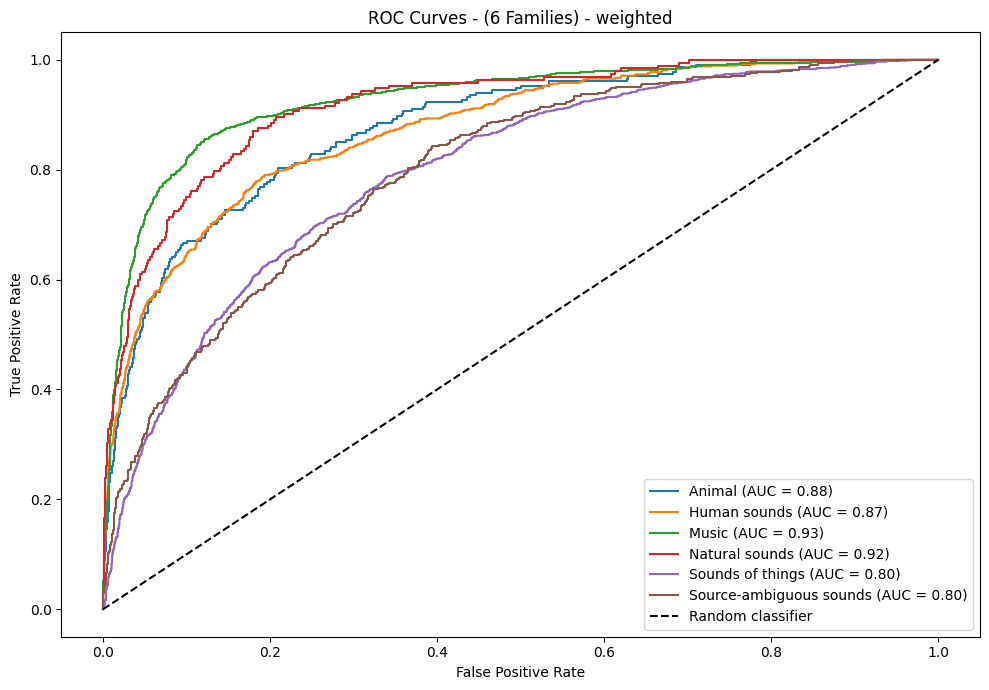

Mean Average Precision (mAP): 0.5752


: 

In [ ]:
# --- Get predicted probabilities for all val samples ---
model.eval()
all_probs = []
with torch.no_grad():
    for i in range(0, len(X_val_t_device), 256):
        xb = X_val_t_device[i:i+256]
        probs = torch.softmax(model(xb), dim=1).cpu().numpy()
        all_probs.append(probs)

all_probs = np.vstack(all_probs)  # (n_val_samples, 6)

# --- Binarize true labels for one-vs-rest ---
y_val_np = y_val_t.numpy()
y_bin = label_binarize(y_val_np, classes=list(range(n_classes)))  # (n_val_samples, 6)

# --- Plot ROC curves ---
plt.figure(figsize=(10, 7))
for i, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - (6 Families) - weighted")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#calculate the Mean accurate prediction (mAP) for the validation set
from sklearn.metrics import average_precision_score
mAP = average_precision_score(y_bin, all_probs, average="macro")
print(f"Mean Average Precision (mAP): {mAP:.4f}")


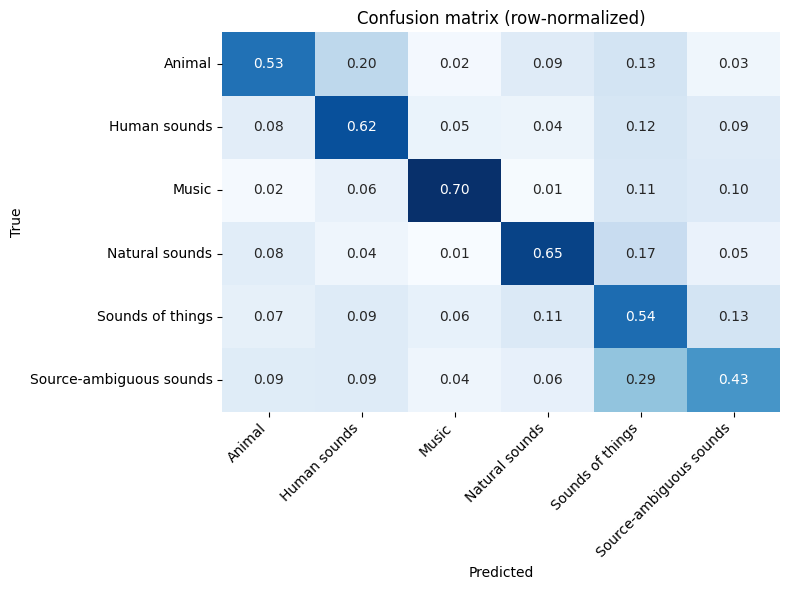

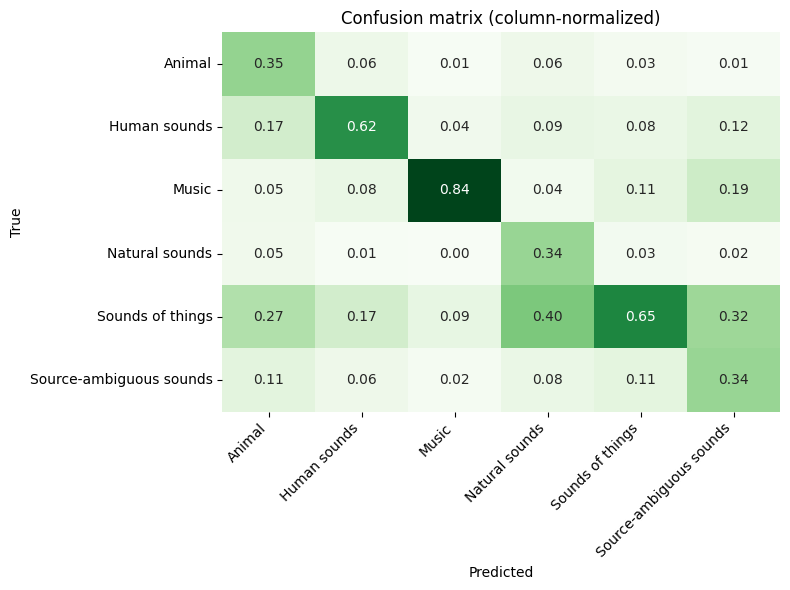

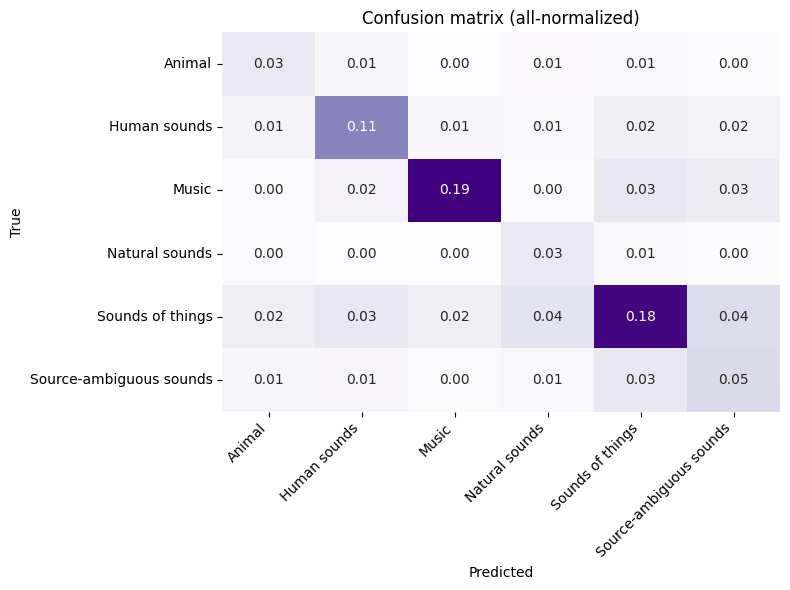

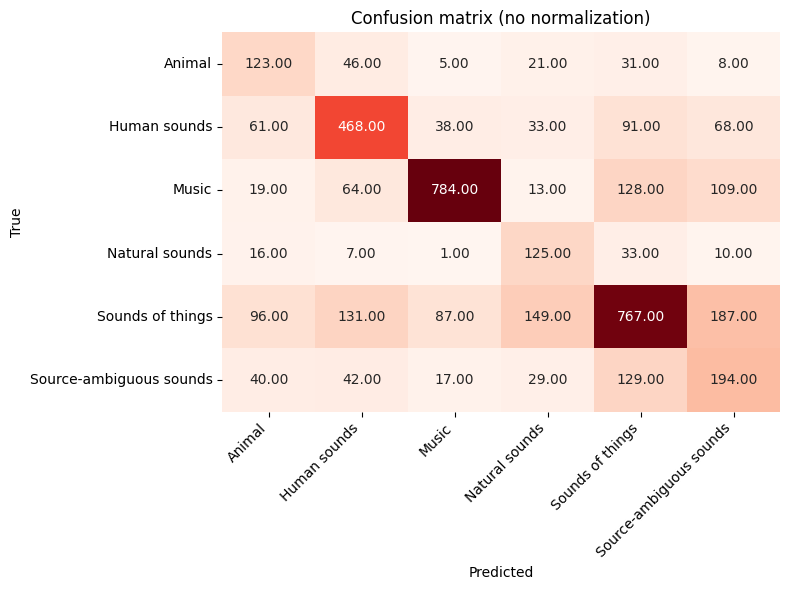

: 

In [ ]:
# Get predictions on validation set
model.eval()
all_preds = []
with torch.no_grad():
    for i in range(0, len(X_val_t_device), 256):
        xb = X_val_t_device[i:i+256]
        preds = model(xb).argmax(1).cpu()
        all_preds.append(preds)

all_preds = torch.cat(all_preds).numpy()
y_val_np  = y_val_t.numpy()

# Confusion matrix
cm = confusion_matrix(y_val_np, all_preds, normalize='true')
cm_pred = confusion_matrix(y_val_np, all_preds, normalize='pred')
cm_all = confusion_matrix(y_val_np, all_preds, normalize='all')
cm_numbers = confusion_matrix(y_val_np, all_preds, normalize=None)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (row-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix{}.png".format(datetime.now().strftime('%Y-%m-%d %H:%M')), dpi=300)  # Save the confusion matrix as a high-resolution image
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pred, annot=True, fmt='.2f', cmap='Greens', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (column-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_all, annot=True, fmt='.2f', cmap='Purples', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (all-normalized)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_numbers, annot=True, fmt='.2f', cmap='Reds', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix (no normalization)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()